In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('YoutubeCommentsDataSet.csv')

In [3]:
df.head()

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


In [4]:
df.isnull().sum()

Comment      44
Sentiment     0
dtype: int64

In [5]:
pip install evaluate transformers datasets scikit-learn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install --upgrade transformers



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install --upgrade transformers datasets


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached pyarrow-22.0.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (3.2 kB)
Using cached pyarrow-22.0.0-cp312-cp312-macosx_12_0_arm64.whl (34.2 MB)
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 20.0.0
    Uninstalling pyarrow-20.0.0:
      Successfully uninstalled pyarrow-20.0.0
  Attempting uninstall: datasets━━━━━━━━━━━━━━━━ 0/2 [pyarrow]
    Found existing installation: datasets 4.0.0m 0/2 [pyarrow]
    Uninstalling datasets-4.0.0:━━━━━━━━━━━━ 0/2 [pyarrow]
      Successfully uninstalled datasets-4.0.0 0/2 [pyarrow]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [datasets]1/2 [datasets]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
# train_sentiment_mps_final.py
import os
import random
import numpy as np
import torch
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, TrainingArguments, Trainer
)
from sklearn.preprocessing import LabelEncoder
import evaluate
from collections import Counter

# ------- USER SETTINGS -------
CSV_PATH = "YoutubeCommentsDataSet.csv"   # CSV with Comment / comment and Sentiment / sentiment
MODEL_NAME = "distilroberta-base"
RANDOM_SEED = 42
TRAIN_SAMPLE_SIZE = 6000
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 4
OUTPUT_DIR = "./sentiment_distilroberta"
# -----------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)

# reproducibility
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

import transformers
print("transformers version:", transformers.__version__)
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available(), "MPS available:", torch.backends.mps.is_available())

# 1) load CSV
ds = load_dataset("csv", data_files=CSV_PATH)["train"]
print("Loaded dataset. Columns:", ds.column_names, "Rows:", len(ds))

# detect columns (case-insensitive common names)
possible_text_cols = ["comment", "Comment", "text", "Text", "comments", "Comments"]
possible_label_cols = ["sentiment", "Sentiment", "label", "Label", "polarity"]

text_col = next((c for c in possible_text_cols if c in ds.column_names), None)
label_col = next((c for c in possible_label_cols if c in ds.column_names), None)
if text_col is None or label_col is None:
    raise ValueError(f"Could not find text/label columns. Available: {ds.column_names}")
print(f"Using text column: '{text_col}', label column: '{label_col}'")

# quick label preview
sample_labels = [str(x) for x in ds.select(range(min(200, len(ds))))[label_col]]
print("Sample label counts (first 200):", Counter(sample_labels))

# 2) encode labels
le = LabelEncoder()
raw_labels = [str(x) for x in ds[label_col]]
le.fit(raw_labels)
encoded = le.transform(raw_labels)
classes = list(le.classes_)
label2id = {c: i for i, c in enumerate(classes)}
id2label = {i: c for c, i in label2id.items()}
print("Detected classes:", classes)

# normalized dataset with 'text' and 'label'
data_list = [{"text": ds[i][text_col], "label": int(encoded[i])} for i in range(len(ds))]
dataset_all = Dataset.from_list(data_list)
print("Normalized dataset columns:", dataset_all.column_names)

# 3) stratified split
y = [ex["label"] for ex in dataset_all]
idx = list(range(len(y)))
train_idx, temp_idx, y_train, y_temp = train_test_split(idx, y, test_size=0.4, random_state=RANDOM_SEED, stratify=y)
val_idx, test_idx, y_val, y_test = train_test_split(temp_idx, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp)

train_ds = dataset_all.select(train_idx)
val_ds = dataset_all.select(val_idx)
test_ds = dataset_all.select(test_idx)
print(f"Splits -> train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

# 4) stratified subsample train if requested
if TRAIN_SAMPLE_SIZE and TRAIN_SAMPLE_SIZE < len(train_ds):
    import pandas as pd
    df_train = pd.DataFrame(train_ds)
    counts = df_train["label"].value_counts().to_dict()
    unique_labels = sorted(df_train["label"].unique())
    target_counts = {}
    for lab in unique_labels:
        prop = counts[lab] / len(df_train)
        target_counts[lab] = max(1, int(round(prop * TRAIN_SAMPLE_SIZE)))
    samples = []
    for lab, cnt in target_counts.items():
        cls_df = df_train[df_train["label"] == lab]
        replace = cnt > len(cls_df)
        samples.append(cls_df.sample(n=cnt, random_state=RANDOM_SEED, replace=replace))
    df_sampled = pd.concat(samples).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    train_ds = Dataset.from_pandas(df_sampled)
    if "_index" in train_ds.column_names:
        train_ds = train_ds.remove_columns(["_index"])
    print(f"Subsampled train -> {len(train_ds)} examples (stratified)")
else:
    print("Using full training set:", len(train_ds))

# 5) tokenizer + tokenization
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def preprocess_fn(examples):
    texts = examples.get("text")
    if texts is None:
        k = list(examples.keys())[0]
        texts = examples[k]
    if isinstance(texts, str) or not hasattr(texts, "__iter__"):
        texts = [texts]
    normalized = [("" if t is None else str(t)) for t in texts]
    return tokenizer(normalized, truncation=True, padding=False, max_length=MAX_LENGTH)

train_ds = train_ds.map(preprocess_fn, batched=True)
val_ds = val_ds.map(preprocess_fn, batched=True)
test_ds = test_ds.map(preprocess_fn, batched=True)

# remove original text column if present
for d in (train_ds, val_ds, test_ds):
    if "text" in d.column_names:
        try:
            d.remove_columns(["text"])
        except Exception:
            pass

train_ds = train_ds.with_format("torch")
val_ds = val_ds.with_format("torch")
test_ds = test_ds.with_format("torch")

# 6) model
num_labels = len(classes)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label={i: classes[i] for i in range(num_labels)},
    label2id={classes[i]: i for i in range(num_labels)}
)
print("Model loaded:", MODEL_NAME)

# 7) collator & metrics
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(pred):
    logits = pred.predictions
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    acc = accuracy.compute(predictions=preds, references=pred.label_ids)["accuracy"]
    f1_macro = f1.compute(predictions=preds, references=pred.label_ids, average="macro")["f1"]
    return {"accuracy": acc, "f1_macro": f1_macro}

# 8) minimal TrainingArguments (safe)
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    num_train_epochs=EPOCHS,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir=os.path.join(OUTPUT_DIR, "logs"),
    logging_steps=100,
    save_total_limit=2,
)

# 9) Trainer (NO EarlyStoppingCallback to keep compatibility)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# 10) train
train_result = trainer.train()
print("Training finished. Trainer output:", train_result)

# 11) evaluate
print("Evaluating on test set...")
res = trainer.evaluate(eval_dataset=test_ds)
print(res)

# 12) inference helper & save label_map
def predict_text(text):
    enc = tokenizer(text, truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
    enc = {k: v.to(trainer.model.device) for k, v in enc.items()}
    with torch.no_grad():
        out = trainer.model(**enc)
        logits = out.logits
        pred = int(torch.argmax(logits, dim=-1).cpu().numpy()[0])
    return classes[pred]

print("Example pred:", predict_text("I love this video!"))

import json
with open(os.path.join(OUTPUT_DIR, "label_map.json"), "w") as f:
    json.dump({"id2label": {str(k): v for k, v in id2label.items()}, "label2id": label2id}, f)
print("Saved label_map.json")


transformers version: 4.57.1
torch version: 2.7.0
CUDA available: False MPS available: True
Loaded dataset. Columns: ['Comment', 'Sentiment'] Rows: 18408
Using text column: 'Comment', label column: 'Sentiment'
Sample label counts (first 200): Counter({'positive': 132, 'neutral': 35, 'negative': 33})
Detected classes: ['negative', 'neutral', 'positive']
Normalized dataset columns: ['text', 'label']
Splits -> train: 11044, val: 3682, test: 3682
Subsampled train -> 5999 examples (stratified)


Map: 100%|██████████| 3682/3682 [00:00<00:00, 35861.16 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: distilroberta-base


/var/folders/bn/r0swyp551bq4_yrsy5w84dth0000gn/T/ipykernel_14171/2185201068.py:173: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
100,0.670500
200,0.465100
300,0.442100
400,0.365100
500,0.285100
600,0.322200
700,0.299600
800,0.251000
900,0.220300
1000,0.192900


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training finished. Trainer output: TrainOutput(global_step=1500, training_loss=0.28712335268656414, metrics={'train_runtime': 581.1615, 'train_samples_per_second': 41.29, 'train_steps_per_second': 2.581, 'total_flos': 674518429494072.0, 'train_loss': 0.28712335268656414, 'epoch': 4.0})
Evaluating on test set...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.5054420232772827, 'eval_accuracy': 0.8614883215643672, 'eval_f1_macro': 0.8165726965201529, 'eval_runtime': 32.6621, 'eval_samples_per_second': 112.73, 'eval_steps_per_second': 3.552, 'epoch': 4.0}
Example pred: positive
Saved label_map.json


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


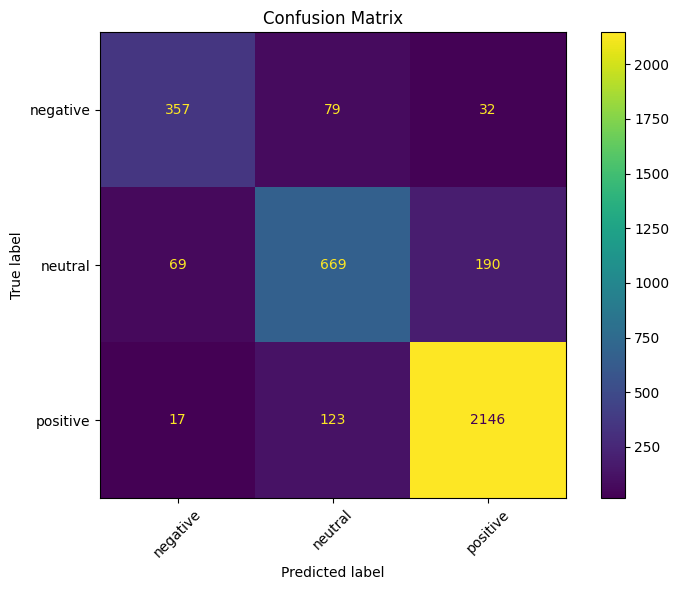

Classification report (per-class):
              precision    recall  f1-score   support

    negative       0.81      0.76      0.78       468
     neutral       0.77      0.72      0.74       928
    positive       0.91      0.94      0.92      2286

    accuracy                           0.86      3682
   macro avg       0.83      0.81      0.82      3682
weighted avg       0.86      0.86      0.86      3682



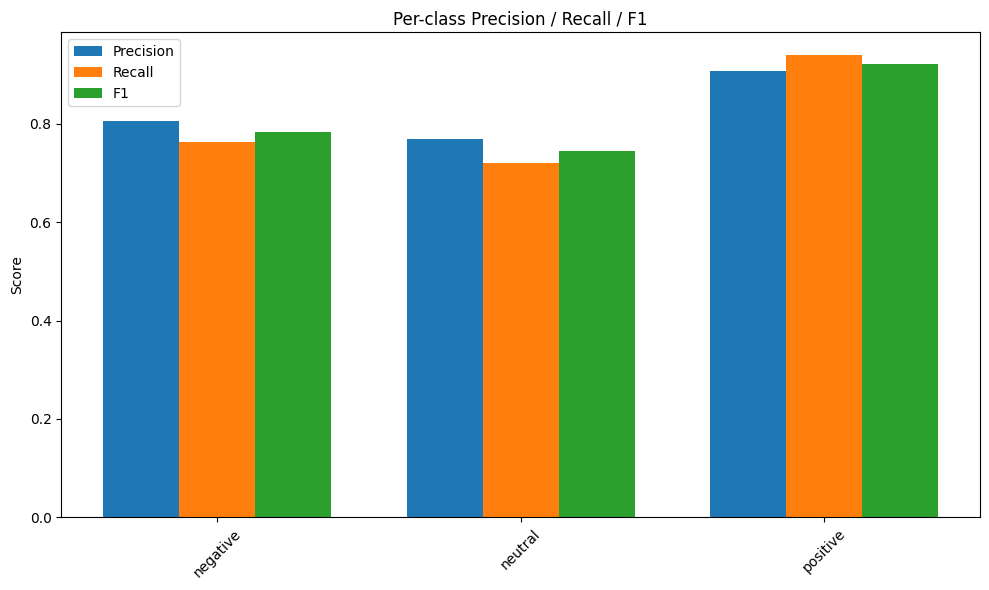

/var/folders/bn/r0swyp551bq4_yrsy5w84dth0000gn/T/ipykernel_14171/1666437972.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(pred_counts.keys()), rotation=45)


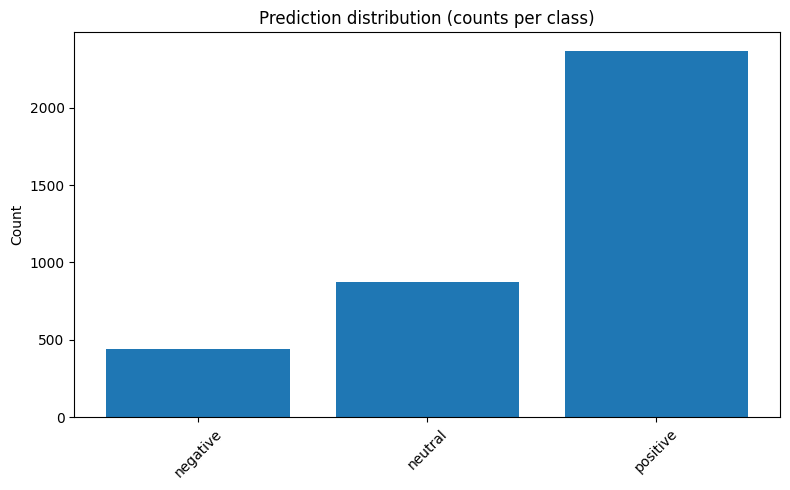

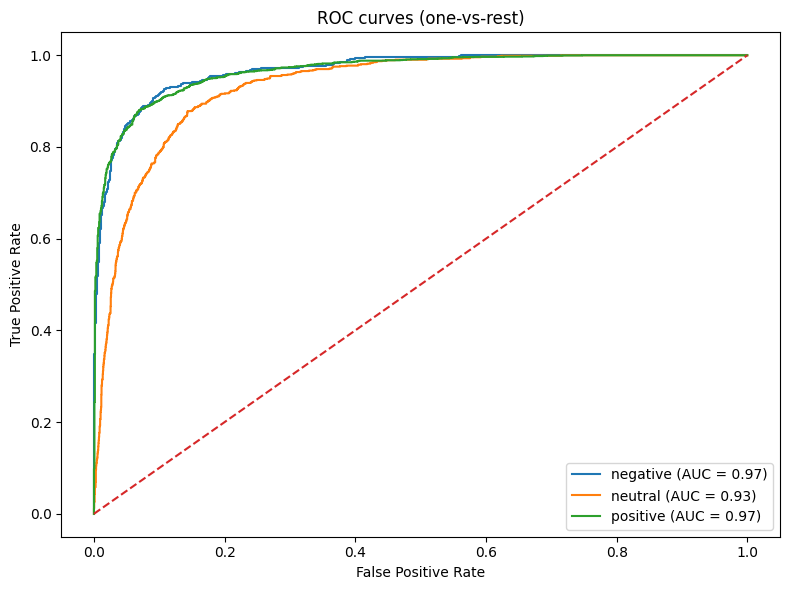

Saved 510 misclassified entries (index only) to ./sentiment_distilroberta/plots/misclassified_examples.csv
Saved metrics summary to ./sentiment_distilroberta/plots/metrics_summary.json
All plots saved to ./sentiment_distilroberta/plots


In [12]:
# Visualization utilities for a trained HuggingFace Trainer model
# Run this cell in the same session where trainer, tokenizer, test_ds, and classes exist.

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import json

# ---------- Settings ----------
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

# ---------- 1) Get predictions on test set ----------
# If you already have predictions saved, skip this block and load them.
pred_out = trainer.predict(test_ds)   # returns PredictionOutput(predictions, label_ids, metrics)
logits = pred_out.predictions
if isinstance(logits, tuple):
    logits = logits[0]
y_true = pred_out.label_ids
y_pred = np.argmax(logits, axis=-1)
y_scores = None
# if you want probability scores (softmax):
from scipy.special import softmax
y_scores = softmax(logits, axis=1) if logits is not None else None

# ---------- 2) Confusion Matrix (heatmap) ----------
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "confusion_matrix.png"))
plt.show()

# ---------- 3) Classification report & per-class bar chart ----------
report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
# print readable report
print("Classification report (per-class):")
print(classification_report(y_true, y_pred, target_names=classes))

# per-class precision/recall/f1 arrays
precisions, recalls, f1s, supports = precision_recall_fscore_support(y_true, y_pred, average=None, labels=list(range(len(classes))))

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, precisions, width, label="Precision")
ax.bar(x, recalls, width, label="Recall")
ax.bar(x + width, f1s, width, label="F1")
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45)
ax.set_ylabel("Score")
ax.set_title("Per-class Precision / Recall / F1")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "per_class_prf.png"))
plt.show()

# ---------- 4) Prediction distribution (counts) ----------
unique, counts = np.unique(y_pred, return_counts=True)
pred_counts = dict(zip([classes[int(u)] for u in unique], counts))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(pred_counts.keys(), pred_counts.values())
ax.set_title("Prediction distribution (counts per class)")
ax.set_ylabel("Count")
ax.set_xticklabels(list(pred_counts.keys()), rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "prediction_distribution.png"))
plt.show()

# ---------- 5) ROC curves (one-vs-rest) if multi-class and if y_scores available ----------
num_classes = len(classes)
if num_classes > 2 and y_scores is not None:
    # Binarize true labels
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        ax.plot(fpr[i], tpr[i], label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})")
    ax.plot([0,1], [0,1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC curves (one-vs-rest)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "roc_one_vs_rest.png"))
    plt.show()
elif num_classes == 2 and y_scores is not None:
    # binary ROC
    from sklearn.metrics import roc_auc_score
    fpr, tpr, _ = roc_curve(y_true, y_scores[:, 1])
    roc_auc_val = roc_auc_score(y_true, y_scores[:, 1])
    fig, ax = plt.subplots(figsize=(6,6))
    ax.plot(fpr, tpr, label=f"AUC = {roc_auc_val:.2f}")
    ax.plot([0,1], [0,1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC curve")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "roc_binary.png"))
    plt.show()
else:
    print("ROC: skipped (need probability scores and at least 2 classes).")

# ---------- 6) Save misclassified examples to CSV for inspection ----------
import pandas as pd
mis_idx = np.where(y_true != y_pred)[0]
rows = []
# test_ds may be a Dataset object with input_ids etc; we kept original text column removed.
# If you still have the original text values available somewhere, replace the lookup below.
# Otherwise, re-create a dataset of raw texts before tokenization or reload CSV and align indices.
try:
    # attempt to get original texts from dataset_all split mapping
    # compute mapping from dataset_all indices to test indices used earlier
    # NOTE: If you want exact raw texts, best to save them before tokenization in a parallel column.
    for i in mis_idx:
        rows.append({
            "true_label": classes[int(y_true[i])],
            "pred_label": classes[int(y_pred[i])],
            "index": int(i)
        })
    df_mis = pd.DataFrame(rows)
    df_mis.to_csv(os.path.join(PLOTS_DIR, "misclassified_examples.csv"), index=False)
    print(f"Saved {len(df_mis)} misclassified entries (index only) to {os.path.join(PLOTS_DIR, 'misclassified_examples.csv')}")
except Exception as e:
    print("Could not save misclassified examples (raw text not available). Error:", e)

# ---------- 7) Save overall metrics to JSON ----------
metrics = {
    "accuracy": float(np.mean(y_pred == y_true)),
    "classification_report": {c: report[c] for c in report if c in classes or c in ("macro avg", "weighted avg")}
}
with open(os.path.join(PLOTS_DIR, "metrics_summary.json"), "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved metrics summary to", os.path.join(PLOTS_DIR, "metrics_summary.json"))

print("All plots saved to", PLOTS_DIR)
